## EDA

In [1]:
import os
import typing
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from badwords import ProfanityFilter
import re
from tqdm import tqdm

Немного пришечем данные: вынесем в отдельный столбец `mixed_class` флаг смешанного класса, `toxicity_class` строка-перечисление классов без префикса \_\_lable\_\_ через запятую, `message_text` - cам текст комментария.

In [2]:
def is_mixed_class(row: str) -> bool:
    sep_idx = row.index(" ")
    return len(row[:sep_idx].split(",")) > 1

def define_toxicity_class(row: str) -> str:
    sep_idx = row.index(" ")
    classes = row[:sep_idx].split(",")
    return ",".join([class_name[9:] for class_name in classes])

def extract_message_text(row: str) -> str:
    sep_idx = row.index(" ")
    return row[sep_idx + 1:]

In [3]:
lines = []
with open(os.path.expanduser("../dataset.txt"), "r") as file:
    lines = [line.rstrip() for line in file.readlines()]
data = pd.DataFrame(lines, columns=["raw_text"])
data["mixed_class"] = data["raw_text"].apply(is_mixed_class)
data["toxicity_class"] = data["raw_text"].apply(define_toxicity_class)
data["message_text"] = data["raw_text"].apply(extract_message_text)
data[["message_text", "toxicity_class", "mixed_class"]].describe()

,message_text,toxicity_class,mixed_class
count,248290,248290,248290
unique,248284,8,2
top,расстрелять нахуй,NORMAL,False
freq,2,203685,239957


In [4]:
data["mixed_class"].mean()

0.03356156107777196

Доля смешанных классов мала (всего 3%), поэтому в первом приближении можно пытаться решить задачу без них. Если потом появятся идеи как их можно использовать -- добавим обратно

In [5]:
clean_data = data[data["mixed_class"] == False][["message_text", "toxicity_class"]]
clean_data.drop_duplicates(subset=["message_text"], inplace=True)
clean_data["toxicity_class"].value_counts()

toxicity_class
NORMAL       203682
INSULT        28567
THREAT         5457
OBSCENITY      2245
Name: count, dtype: int64

Добавим примитивные численные признаки построенные по сообщению, чтобы оценить наличие выбросов по длине и составу символов.

In [6]:
clean_data["words"] = clean_data["message_text"].apply(lambda text: [word for word in text.split() if len(word) > 0])
clean_data["word_count"] = clean_data["words"].apply(lambda words: len(words))
clean_data["upper_case"] = clean_data["words"].apply(lambda words: any([word.isupper() for word in words]))
clean_data["symbol_count"] = clean_data["message_text"].apply(lambda text: sum([1 for symbol in text if not symbol.isspace()]))

In [7]:
for word in tqdm(clean_data.iloc[0]['words']):
    print(word)
    pf = ProfanityFilter()
    pf.init(['ru'])
    print(pf.filter_text(word, match_threshold=0.99))

100%|██████████| 3/3 [00:00<00:00, 22.81it/s]

скотина!
True
что
False
сказать
False


In [8]:
# mat = ['бля', "хуй", "пизд", "еба"]
# clean_data["swearing"] = clean_data["message_text"].apply(lambda text: sum([m in text for m in mat]) > 0)

In [9]:
clean_data["toxic"] = clean_data["toxicity_class"] != "NORMAL"

In [10]:
# tqdm.pandas()

# clean_data["profanity"] = clean_data["message_text"].progress_apply(lambda text: pf.filter_text(text, match_threshold=0.99))

In [11]:
swearing_pattern = "(?iu)(?<![а-яё])(?:(?:(?:у|[нз]а|(?:хитро|не)?вз?[ыьъ]|с[ьъ]|(?:и|ра)[зс]ъ?|(?:о[тб]|п[оа]д)[ьъ]?|(?:\S(?=[а-яё]))+?[оаеи-])-?)?(?:[её](?:б(?!о[рй]|рач)|п[уа](?:ц|тс))|и[пб][ае][тцд][ьъ]).*?|(?:(?:н[иеа]|(?:ра|и)[зс]|[зд]?[ао](?:т|дн[оа])?|с(?:м[еи])?|а[пб]ч|в[ъы]?|пр[еи])-?)?ху(?:[яйиеёю]|л+и(?!ган)).*?|бл(?:[эя]|еа?)(?:[дт][ьъ]?)?|\S*?(?:п(?:[иеё]зд|ид[аое]?р|ед(?:р(?!о)|[аое]р|ик)|охую)|бля(?:[дбц]|тс)|[ое]ху[яйиеё]|хуйн).*?|(?:о[тб]?|про|на|вы)?м(?:анд(?:[ауеыи](?:л(?:и[сзщ])?[ауеиы])?|ой|[ао]в.*?|юк(?:ов|[ауи])?|е[нт]ь|ища)|уд(?:[яаиое].+?|е?н(?:[ьюия]|ей))|[ао]л[ао]ф[ьъ](?:[яиюе]|[еёо]й))|елд[ауые].*?|ля[тд]ь|(?:[нз]а|по)х)(?![а-яё])"

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
/var/folders/4p/4cl76w7n2wd8f5rtvp0y4zb00000gn/T/ipykernel_89193/966258144.py:1: SyntaxWarning: invalid escape sequence '\S'
  swearing_pattern = "(?iu)(?<![а-яё])(?:(?:(?:у|[нз]а|(?:хитро|не)?вз?[ыьъ]|с[ьъ]|(?:и|ра)[зс]ъ?|(?:о[тб]|п[оа]д)[ьъ]?|(?:\S(?=[а-яё]))+?[оаеи-])-?)?(?:[её](?:б(?!о[рй]|рач)|п[уа](?:ц|тс))|и[пб][ае][тцд][ьъ]).*?|(?:(?:н[иеа]|(?:ра|и)[зс]|[зд]?[ао](?:т|дн[оа])?|с(?:м[еи])?|а[пб]ч|в[ъы]?|пр[еи])-?)?ху(?:[яйиеёю]|л+и(?!ган)).*?|бл(?:[эя]|еа?)(?:[дт][ьъ]?)?|\S*?(?:п(?:[иеё]зд|ид[аое]?р|ед(?:р(?!о)|[аое]р|ик)|охую)|бля(?:[дбц]|тс)|[ое]ху[яйиеё]|хуйн).*?|(?:о[тб]?|про|на|вы)?м(?:анд(?:[ауеыи](?:л(?:и[сзщ])?[ауеиы])?|ой|[ао]в.*?|юк(?:ов|[ауи])?|е[нт]ь|ища)|уд(?:[яаиое].+?|е?н(?:[ьюия]|ей))|[ао]л[ао]ф[ьъ](?:[яиюе]|[еёо]й))|елд[ауые].*?|ля[тд]ь|(?:[нз]а|по)х)(?![а-яё])"


In [12]:
clean_data["swearing"] = clean_data["message_text"].apply(lambda text: bool(re.search(swearing_pattern, text)))

In [13]:
emoji_pattern = re.compile("["
    u"\U0001F600-\U0001F64F"  # смайлики
    u"\U0001F300-\U0001F5FF"  # символы и пиктограммы
    u"\U0001F680-\U0001F6FF"  # транспортные символы и карты
    u"\U0001F1E0-\U0001F1FF"  # флаги
    "]+", flags=re.UNICODE)
clean_data["has_emoji"] = clean_data["message_text"].apply(lambda text: bool(re.search(emoji_pattern, text)))

In [ ]:
# positive_emoji_pattern_perp = re.compile(
#     u'[\U0001F600-\U0001F64F'  # улыбки
#     u'\U0001F44D'              # палец вверх
#     u'\u270A-\u270D]'          # жесты руками
# )
# negative_emoji_pattern_perp = re.compile(
#     u'[\U0001F44E'  # палец вниз
#     u'\U0001F4A9]'  # "говно"
# )
# adult_emoji_pattern_perp = re.compile(
#     u'[\U0001F346'  # 🍆 баклажан
#     u'\U0001F351'   # 🍑 персик
#     u'\U0001F445'   # 👅 язык
#     u'\U0001F4A6'   # 💦 капельки
#     u'\U0001F34C'   # 🍌 банан
#     u'\U0001F459]'  # 👙 купальник
# )
# clean_data["has_positive_emoji"] = clean_data["message_text"].apply(lambda text: bool(re.search(positive_emoji_pattern_perp, text)))
# clean_data["has_negative_emoji"] = clean_data["message_text"].apply(lambda text: bool(re.search(negative_emoji_pattern_perp, text)))
# clean_data["has_obscene_emoji"] = clean_data["message_text"].apply(lambda text: bool(re.search(adult_emoji_pattern_perp, text)))

In [15]:
# 😊👍🤗 — позитивные смайлы, жесты и символы
positive_emoji_pattern_chgpt = re.compile(
    u'['
    u'\U0001F600-\U0001F64F'  # смайлы (улыбки, радость, обнимашки и т.п.)
    u'\U0001F44D'              # 👍 палец вверх
    u'\U0001F44C'              # 👌 всё ок
    u'\U0001F64C'              # 🙌 поднятые руки
    u'\u270A-\u270D'           # ✊✋✌ жесты руками
    u'\U0001F929'              # 🤩 восторг
    u'\U0001F973'              # 🥳 праздник
    u'\u2764\uFE0F'            # ❤️ сердце
    u'\U0001F49A-\U0001F49F'   # 💚💛💜💗 и т.п.
    u'\U0001F607'              # 😇 нимб
    u'\U0001F4AA'              # 💪 сила
    u'\U0001F44F'              # 👏 аплодисменты
    u']'
)

# 👎💩😡 — негативные эмоции и символы
negative_emoji_pattern_chgpt = re.compile(
    u'['
    u'\U0001F44E'  # 👎 палец вниз
    u'\U0001F621'  # 😡 злость
    # u'\U0001F620'  # 😠 сердитый
    # u'\U0001F624'  # 😤 раздражение
    u'\U0001F92C'  # 🤬 матерный
    u'\U0001F4A9'  # 💩 "говно"
    # u'\U0001F494'  # 💔 разбитое сердце
    u']'
)

# 🍆🍑💦👅💋🔥 — часто используемые в сексуальном контексте эмодзи
adult_emoji_pattern_chgpt = re.compile(
    u'['
    u'\U0001F346'  # 🍆 баклажан
    u'\U0001F351'  # 🍑 персик
    u'\U0001F34C'  # 🍌 банан
    u'\U0001F445'  # 👅 язык
    # u'\U0001F48B'  # 💋 поцелуй
    u'\U0001F4A6'  # 💦 капельки
    u']'
)

# Применение к DataFrame
clean_data["has_positive_emoji"] = clean_data["message_text"].apply(
    lambda text: bool(re.search(positive_emoji_pattern_chgpt, str(text)))
)
clean_data["has_negative_emoji"] = clean_data["message_text"].apply(
    lambda text: bool(re.search(negative_emoji_pattern_chgpt, str(text)))
)
clean_data["has_obscene_emoji"] = clean_data["message_text"].apply(
    lambda text: bool(re.search(adult_emoji_pattern_chgpt, str(text)))
)


In [16]:
# clean_data[clean_data['symbol_count'] > clean_data['symbol_count'].quantile(0.999)]

In [17]:
# for i in clean_data[(clean_data['toxic'] == False) & (clean_data['swearing'])]['message_text']:
#     print(i)
#     print()

In [18]:
clean_data.groupby('swearing')['toxic'].mean()

swearing
False    0.085714
True     0.979285
Name: toxic, dtype: float64

In [19]:
clean_data.groupby('has_emoji')['toxic'].mean()

has_emoji
False    0.155631
True     0.096850
Name: toxic, dtype: float64

In [20]:
clean_data.groupby('has_negative_emoji')['toxic'].mean()

has_negative_emoji
False    0.149578
True     0.493176
Name: toxic, dtype: float64

In [21]:
clean_data.groupby('has_positive_emoji')['toxic'].mean()

has_positive_emoji
False    0.156213
True     0.080432
Name: toxic, dtype: float64

In [22]:
clean_data.groupby('has_obscene_emoji')['toxic'].mean()

has_obscene_emoji
False    0.151131
True     0.303030
Name: toxic, dtype: float64

In [23]:
clean_data[(clean_data.toxic) & ~(clean_data.swearing)]

,message_text,toxicity_class,words,word_count,upper_case,symbol_count,toxic,swearing,has_emoji,has_positive_emoji,has_negative_emoji,has_obscene_emoji
0,скотина! что сказать,INSULT,"[скотина!, что, сказать]",3,False,18,True,False,False,False,False,False
34,"мляяя..фомин..ты издесь умничаешь,чайка помойн...",INSULT,"[мляяя..фомин..ты, издесь, умничаешь,чайка, по...",12,False,110,True,False,False,False,False,False
44,он сразу подписал себе приговор звание - пусто...,INSULT,"[он, сразу, подписал, себе, приговор, звание, ...",29,False,165,True,False,False,False,False,False
51,украина территория населенная ублюдками👎,INSULT,"[украина, территория, населенная, ублюдками👎]",4,False,37,True,False,True,False,True,False
67,эти генеральши знают где соснуть и раздвинуть ...,OBSCENITY,"[эти, генеральши, знают, где, соснуть, и, разд...",12,False,62,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
248228,поганые уроды-им нужно сделать тоже самое,INSULT,"[поганые, уроды-им, нужно, сделать, тоже, самое]",6,False,36,True,False,False,False,False,False
248255,"украина в канаде, крым в россии, карабас в жопе.",INSULT,"[украина, в, канаде,, крым, в, россии,, караба...",9,False,40,True,False,False,False,False,False
248259,такую ребенка как можно бросит ее убить надо ее,THREAT,"[такую, ребенка, как, можно, бросит, ее, убить...",9,False,39,True,False,False,False,False,False
248265,"плохой актёр, поганый человек(если можно челов...",INSULT,"[плохой, актёр,, поганый, человек(если, можно,...",28,False,169,True,False,False,False,False,False


In [24]:
clean_data[(clean_data.toxic) & (clean_data.has_obscene_emoji)]

,message_text,toxicity_class,words,word_count,upper_case,symbol_count,toxic,swearing,has_emoji,has_positive_emoji,has_negative_emoji,has_obscene_emoji
43773,"он что, ебанутый 🍆? :s",INSULT,"[он, что,, ебанутый, 🍆?, :s]",5,False,18,True,True,True,False,False,True
102655,если не будешь сосать 🍌👈тогда мне придётся мам...,OBSCENITY,"[если, не, будешь, сосать, 🍌👈тогда, мне, придё...",13,False,58,True,True,True,False,False,True
131839,харрккк тьфууу! 💦💦 😂 пиздаболка вонючая.,INSULT,"[харрккк, тьфууу!, 💦💦, 😂, пиздаболка, вонючая.]",6,False,35,True,True,True,True,False,True
145564,чёткая!!!!! я бы лизнул 👅,OBSCENITY,"[чёткая!!!!!, я, бы, лизнул, 👅]",5,False,21,True,False,True,False,False,True
151973,",, ты ещё мамаёб?,, фу сука, тебя обосать надо...",INSULT,"[,,, ты, ещё, мамаёб?,,, фу, сука,, тебя, обос...",10,False,43,True,True,True,False,False,True
162202,оо пердушка старая на работу выползла- на чуча...,INSULT,"[оо, пердушка, старая, на, работу, выползла-, ...",10,False,49,True,False,True,False,False,True
166009,кончил бы между грудью в губы тв😍😍💦💦💦💦💦ои,OBSCENITY,"[кончил, бы, между, грудью, в, губы, тв😍😍💦💦💦💦💦ои]",7,False,35,True,False,True,True,False,True
173930,тупой долбаеб без повода кидать в чс🥰🥰🥰🥰🥵🥵🥵🥵🤭🤭...,INSULT,"[тупой, долбаеб, без, повода, кидать, в, чс🥰🥰🥰...",7,False,48,True,True,True,True,False,True
195738,апетитная писечка вылизать бы.👍👍👍👅👅👅,OBSCENITY,"[апетитная, писечка, вылизать, бы.👍👍👍👅👅👅]",4,False,33,True,False,True,True,False,True
214386,отлизать бы 👅,OBSCENITY,"[отлизать, бы, 👅]",3,False,11,True,False,True,False,False,True


In [25]:
import matplotlib.pyplot as plt

toxic_data = clean_data[clean_data['toxic'] == True]
non_toxic_data = clean_data[clean_data['toxic'] == False]

In [26]:
toxic_data.describe()

,word_count,symbol_count
count,36269.000000,36269.000000
mean,13.130332,69.055144
std,15.301217,79.499122
min,1.000000,4.000000
25%,5.000000,25.000000
50%,8.000000,43.000000
75%,15.000000,81.000000
max,171.000000,858.000000


In [27]:
non_toxic_data.describe()

,word_count,symbol_count
count,203682.000000,203682.000000
mean,12.345789,66.026050
std,15.508005,82.087343
min,1.000000,2.000000
25%,4.000000,23.000000
50%,7.000000,39.000000
75%,14.000000,73.000000
max,267.000000,877.000000


In [28]:
max_words_count = clean_data.word_count.max()

In [29]:
probs = {}
for i in range(1, max_words_count + 1, 7):
    toxic_true = len(clean_data[(clean_data['word_count'] == i) &  (clean_data['toxic'])])
    toxic_false = len(clean_data[(clean_data['word_count'] == i) &  (clean_data['toxic'] == False)])
    probs[i] = toxic_true / max(toxic_false, 1)

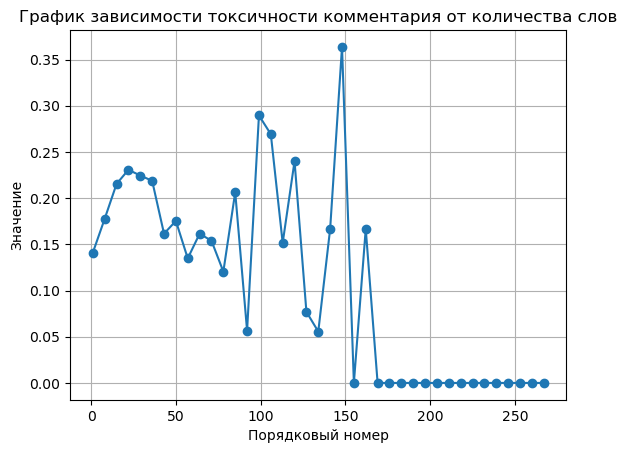

In [30]:
import matplotlib.pyplot as plt

# Ваш словарь с порядковыми номерами и значениями

# Извлекаем ключи и значения для осей X и Y
x = list(probs.keys())    # порядковые номера
y = list(probs.values())  # числовые значения

plt.plot(x, y, marker='o')  # Линейный график с точками

plt.xlabel('Порядковый номер')
plt.ylabel('Значение')
plt.title('График зависимости токсичности комментария от количества слов')
plt.grid(True)

plt.show()